In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

from pathlib import Path
import random
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_CROPS = PROJECT_ROOT / "data" / "crops"
RUNS_DIR = PROJECT_ROOT / "runs" / "baseline_cnn"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("device:", DEVICE)
print("img size:", IMG_SIZE)
print("data crops:", DATA_CROPS)
print("runs dir:", RUNS_DIR)


device: mps
img size: 128
data crops: /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/data/crops
runs dir: /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/runs/baseline_cnn


In [2]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ImageFolder(DATA_CROPS / "train", transform=train_transform)
val_ds = ImageFolder(DATA_CROPS / "val", transform=eval_transform)
test_ds = ImageFolder(DATA_CROPS / "test", transform=eval_transform)

classes = train_ds.classes
print("classes:", classes)
print(f"train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")


classes: ['cattle', 'sheep']
train: 35806, val: 7770, test: 7744


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, n_conv_blocks=3, base_channels=32, kernel_size=3,
                 activation="relu", dropout=0.3, n_classes=2):
        super().__init__()
        act_map = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU, "gelu": nn.GELU}
        Act = act_map[activation]
        layers = []
        in_ch = 3
        out_ch = base_channels
        for _ in range(n_conv_blocks):
            layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size // 2))
            layers.append(nn.BatchNorm2d(out_ch))
            layers.append(Act())
            layers.append(nn.MaxPool2d(2))
            in_ch = out_ch
            out_ch = out_ch * 2
        self.features = nn.Sequential(*layers)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            flat_dim = self.features(dummy).view(1, -1).shape[1]
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128),
            Act(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


demo = SimpleCNN()
print(demo)
print("total params:", sum(p.numel() for p in demo.parameters()))


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=32768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(i

In [4]:
def make_optimizer(name, params, lr):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr)
    return torch.optim.SGD(params, lr=lr, momentum=0.9)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total_correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, total_correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    ys, ps = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            ys.extend(labels.cpu().numpy().tolist())
            ps.extend(out.argmax(1).cpu().numpy().tolist())
    acc = accuracy_score(ys, ps)
    return total_loss / len(loader.dataset), acc, np.array(ys), np.array(ps)


def fit_model(model, train_loader, val_loader, epochs, optimizer, criterion, device, patience=5, verbose=False):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None
    patience_counter = 0
    for epoch in range(epochs):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl, va, _, _ = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        if verbose:
            print(f"  epoch {epoch+1}: train_loss={tl:.4f} train_acc={ta:.4f} val_loss={vl:.4f} val_acc={va:.4f} ({time.time()-t0:.1f}s)")
        if va > best_val_acc:
            best_val_acc = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch+1}")
                break
    return history, best_state, best_val_acc


print("training utilities ready")


training utilities ready


In [5]:
SUBSET_TRAIN = 5000
SUBSET_VAL = 1000
HP_EPOCHS = 5

rng = np.random.RandomState(SEED)
train_idx = rng.choice(len(train_ds), size=SUBSET_TRAIN, replace=False).tolist()
val_idx = rng.choice(len(val_ds), size=SUBSET_VAL, replace=False).tolist()

sub_train = Subset(train_ds, train_idx)
sub_val = Subset(val_ds, val_idx)

print(f"HP subsets: train={len(sub_train)}, val={len(sub_val)}")


def objective(trial):
    n_blocks = trial.suggest_int("n_conv_blocks", 2, 4)
    base_ch = trial.suggest_categorical("base_channels", [16, 32, 64])
    ksz = trial.suggest_categorical("kernel_size", [3, 5])
    act = trial.suggest_categorical("activation", ["relu", "leaky_relu", "gelu"])
    drop = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    bs = trial.suggest_categorical("batch_size", [32, 64, 128])
    opt_name = trial.suggest_categorical("optimizer", ["adam", "adamw", "sgd"])

    model = SimpleCNN(
        n_conv_blocks=n_blocks,
        base_channels=base_ch,
        kernel_size=ksz,
        activation=act,
        dropout=drop,
    ).to(DEVICE)
    optimizer = make_optimizer(opt_name, model.parameters(), lr)
    criterion = nn.CrossEntropyLoss()
    tr_loader = DataLoader(sub_train, batch_size=bs, shuffle=True, num_workers=0)
    val_loader = DataLoader(sub_val, batch_size=bs, shuffle=False, num_workers=0)

    _, _, best_val = fit_model(model, tr_loader, val_loader, HP_EPOCHS,
                                optimizer, criterion, DEVICE, patience=3, verbose=False)
    return best_val


HP subsets: train=5000, val=1000


In [6]:
HP_TRIALS = 15
sampler = TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler,
                             study_name="cnn_baseline",
                             storage=f"sqlite:///{RUNS_DIR / 'optuna.db'}",
                             load_if_exists=True)

t0 = time.time()
study.optimize(objective, n_trials=HP_TRIALS, show_progress_bar=False)
print(f"\nHP search done in {time.time()-t0:.1f}s")
print(f"best val acc: {study.best_value:.4f}")
print("best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


[I 2026-04-23 11:04:23,950] A new study created in RDB with name: cnn_baseline


[I 2026-04-23 11:05:04,309] Trial 0 finished with value: 0.9 and parameters: {'n_conv_blocks': 3, 'base_channels': 16, 'kernel_size': 3, 'activation': 'leaky_relu', 'dropout': 0.35403628889802274, 'lr': 0.00010994335574766199, 'batch_size': 32, 'optimizer': 'sgd'}. Best is trial 0 with value: 0.9.


[I 2026-04-23 11:08:28,709] Trial 1 finished with value: 0.92 and parameters: {'n_conv_blocks': 3, 'base_channels': 64, 'kernel_size': 5, 'activation': 'gelu', 'dropout': 0.09983689107917987, 'lr': 0.0010677482709481358, 'batch_size': 128, 'optimizer': 'sgd'}. Best is trial 1 with value: 0.92.


[I 2026-04-23 11:09:06,981] Trial 2 finished with value: 0.909 and parameters: {'n_conv_blocks': 4, 'base_channels': 16, 'kernel_size': 3, 'activation': 'leaky_relu', 'dropout': 0.45466020103939103, 'lr': 0.00032927591344236165, 'batch_size': 32, 'optimizer': 'sgd'}. Best is trial 1 with value: 0.92.


[I 2026-04-23 11:09:44,044] Trial 3 finished with value: 0.91 and parameters: {'n_conv_blocks': 4, 'base_channels': 16, 'kernel_size': 3, 'activation': 'gelu', 'dropout': 0.194338644844741, 'lr': 0.00034889766548903674, 'batch_size': 32, 'optimizer': 'sgd'}. Best is trial 1 with value: 0.92.


...

[I 2026-04-23 11:20:47,990] Trial 11 finished with value: 0.899 and parameters: {'n_conv_blocks': 3, 'base_channels': 32, 'kernel_size': 5, 'activation': 'relu', 'dropout': 0.006295689993706109, 'lr': 0.0035240007744626873, 'batch_size': 32, 'optimizer': 'adamw'}. Best is trial 8 with value: 0.923.


[I 2026-04-23 11:22:29,225] Trial 12 finished with value: 0.907 and parameters: {'n_conv_blocks': 3, 'base_channels': 32, 'kernel_size': 5, 'activation': 'relu', 'dropout': 0.134120361690769, 'lr': 0.002393719194281379, 'batch_size': 32, 'optimizer': 'adamw'}. Best is trial 8 with value: 0.923.


[I 2026-04-23 11:24:06,451] Trial 13 finished with value: 0.912 and parameters: {'n_conv_blocks': 3, 'base_channels': 32, 'kernel_size': 5, 'activation': 'gelu', 'dropout': 0.039012476606078095, 'lr': 0.0020975457910271662, 'batch_size': 32, 'optimizer': 'adam'}. Best is trial 8 with value: 0.923.


[I 2026-04-23 11:25:44,752] Trial 14 finished with value: 0.901 and parameters: {'n_conv_blocks': 2, 'base_channels': 64, 'kernel_size': 3, 'activation': 'relu', 'dropout': 0.15685565295679038, 'lr': 0.0005779908321591065, 'batch_size': 128, 'optimizer': 'adamw'}. Best is trial 8 with value: 0.923.



HP search done in 1280.8s
best val acc: 0.9230
best params:
  n_conv_blocks: 3
  base_channels: 64
  kernel_size: 3
  activation: relu
  dropout: 0.018443473677266398
  lr: 0.001656260589333597
  batch_size: 32
  optimizer: adam


completed trials: 15

top 5 trials by val acc:
   number  value  params_n_conv_blocks  params_base_channels  params_kernel_size params_activation params_optimizer  params_lr
8       8  0.923                     3                    64                   3              relu             adam   0.001656
7       7  0.922                     3                    32                   5              gelu            adamw   0.001051
1       1  0.920                     3                    64                   5              gelu              sgd   0.001068
6       6  0.920                     2                    32                   5              gelu              sgd   0.007234
9       9  0.920                     3                    16                   3              relu              sgd   0.001179



param importances:
  lr: 0.366
  batch_size: 0.189
  optimizer: 0.143
  n_conv_blocks: 0.131
  dropout: 0.071
  activation: 0.051
  base_channels: 0.028
  kernel_size: 0.019


/var/folders/m7/56qd8wjd2cl8yjq17nwtyvk00000gn/T/ipykernel_17624/3673141833.py:19: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


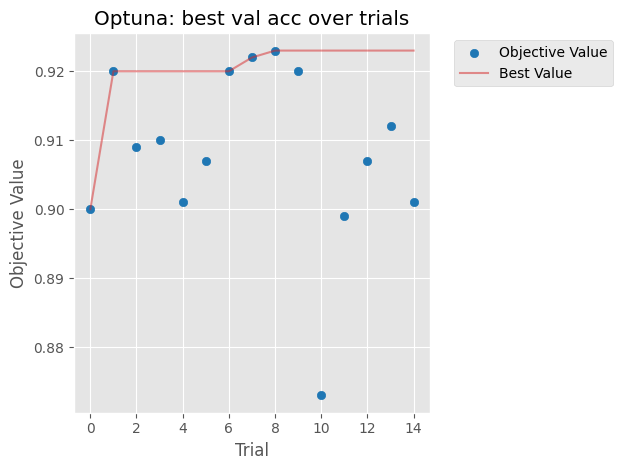

/var/folders/m7/56qd8wjd2cl8yjq17nwtyvk00000gn/T/ipykernel_17624/3673141833.py:24: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


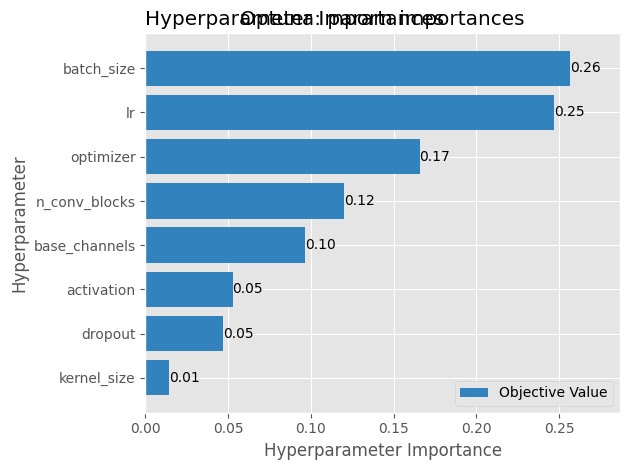

In [7]:
trials_df = study.trials_dataframe()
print(f"completed trials: {len(trials_df)}")
print()
print("top 5 trials by val acc:")
print(trials_df.sort_values("value", ascending=False).head(5)[
    ["number", "value", "params_n_conv_blocks", "params_base_channels",
     "params_kernel_size", "params_activation", "params_optimizer", "params_lr"]
].to_string())

try:
    importances = optuna.importance.get_param_importances(study)
    print()
    print("param importances:")
    for k, v in importances.items():
        print(f"  {k}: {v:.3f}")
except Exception as e:
    print(f"importance calc failed: {e}")

fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna: best val acc over trials")
plt.tight_layout()
plt.show()

fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Optuna: param importances")
plt.tight_layout()
plt.show()


training final model with best HP on full dataset...
{'n_conv_blocks': 3, 'base_channels': 64, 'kernel_size': 3, 'activation': 'relu', 'dropout': 0.018443473677266398, 'lr': 0.001656260589333597, 'batch_size': 32, 'optimizer': 'adam'}


  epoch 1: train_loss=0.4137 train_acc=0.8919 val_loss=0.1809 val_acc=0.9293 (177.9s)


  epoch 2: train_loss=0.2054 train_acc=0.9201 val_loss=0.3191 val_acc=0.8708 (173.2s)


  epoch 3: train_loss=0.1865 train_acc=0.9248 val_loss=0.1804 val_acc=0.9373 (173.3s)


  epoch 4: train_loss=0.1772 train_acc=0.9304 val_loss=0.1804 val_acc=0.9341 (170.6s)


...

  epoch 17: train_loss=0.0950 train_acc=0.9594 val_loss=0.1109 val_acc=0.9569 (185.0s)


  epoch 18: train_loss=0.0960 train_acc=0.9596 val_loss=0.0999 val_acc=0.9600 (185.3s)


  epoch 19: train_loss=0.0893 train_acc=0.9620 val_loss=0.1114 val_acc=0.9595 (187.0s)


  epoch 20: train_loss=0.0890 train_acc=0.9625 val_loss=0.1034 val_acc=0.9593 (188.1s)


  epoch 21: train_loss=0.0861 train_acc=0.9636 val_loss=0.1170 val_acc=0.9583 (189.0s)
  early stop at epoch 21

best val acc on full val: 0.9609
saved model to /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/runs/baseline_cnn/best_cnn.pt


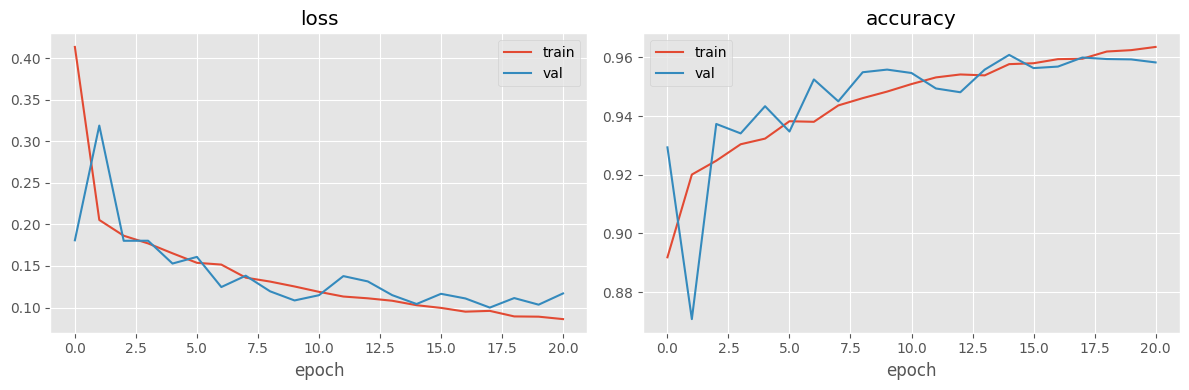

In [8]:
best_params = study.best_params
print("training final model with best HP on full dataset...")
print(best_params)

final_model = SimpleCNN(
    n_conv_blocks=best_params["n_conv_blocks"],
    base_channels=best_params["base_channels"],
    kernel_size=best_params["kernel_size"],
    activation=best_params["activation"],
    dropout=best_params["dropout"],
).to(DEVICE)
final_optimizer = make_optimizer(best_params["optimizer"], final_model.parameters(), best_params["lr"])
criterion = nn.CrossEntropyLoss()

FINAL_EPOCHS = 25
BS = best_params["batch_size"]
full_train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True, num_workers=0)
full_val_loader = DataLoader(val_ds, batch_size=BS, shuffle=False, num_workers=0)

history, best_state, best_val_acc = fit_model(
    final_model, full_train_loader, full_val_loader, FINAL_EPOCHS,
    final_optimizer, criterion, DEVICE, patience=6, verbose=True,
)
print(f"\nbest val acc on full val: {best_val_acc:.4f}")
final_model.load_state_dict(best_state)
torch.save(best_state, RUNS_DIR / "best_cnn.pt")
print("saved model to", RUNS_DIR / "best_cnn.pt")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


test metrics (custom CNN):
  accuracy:  0.9610
  precision: 0.9610
  recall:    0.9606
  f1:        0.9608


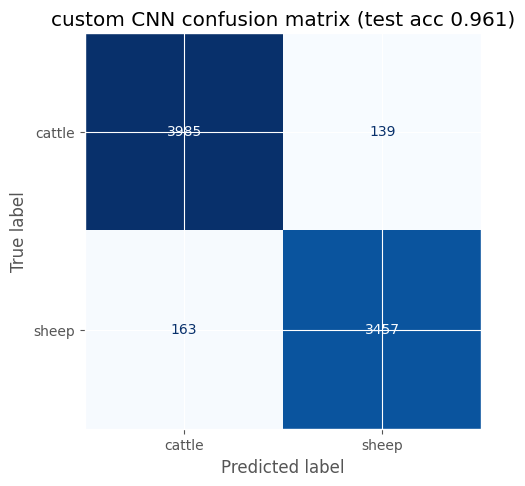


saved /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/runs/baseline_cnn/test_results.json
saved ground truth and predictions for later comparison


In [9]:
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)
test_loss, test_acc, ys, ps = evaluate(final_model, test_loader, criterion, DEVICE)

precision = precision_score(ys, ps, average="macro")
recall = recall_score(ys, ps, average="macro")
f1 = f1_score(ys, ps, average="macro")

print("test metrics (custom CNN):")
print(f"  accuracy:  {test_acc:.4f}")
print(f"  precision: {precision:.4f}")
print(f"  recall:    {recall:.4f}")
print(f"  f1:        {f1:.4f}")

cm = confusion_matrix(ys, ps)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"custom CNN confusion matrix (test acc {test_acc:.3f})")
plt.tight_layout()
plt.show()

results_row = {
    "model": "custom_cnn",
    "best_val_acc": float(best_val_acc),
    "test_acc": float(test_acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "confusion_matrix": cm.tolist(),
    "best_params": best_params,
}
with open(RUNS_DIR / "test_results.json", "w") as f:
    json.dump(results_row, f, indent=2)
print()
print("saved", RUNS_DIR / "test_results.json")

np.save(RUNS_DIR / "test_ys.npy", ys)
np.save(RUNS_DIR / "test_ps.npy", ps)
print("saved ground truth and predictions for later comparison")


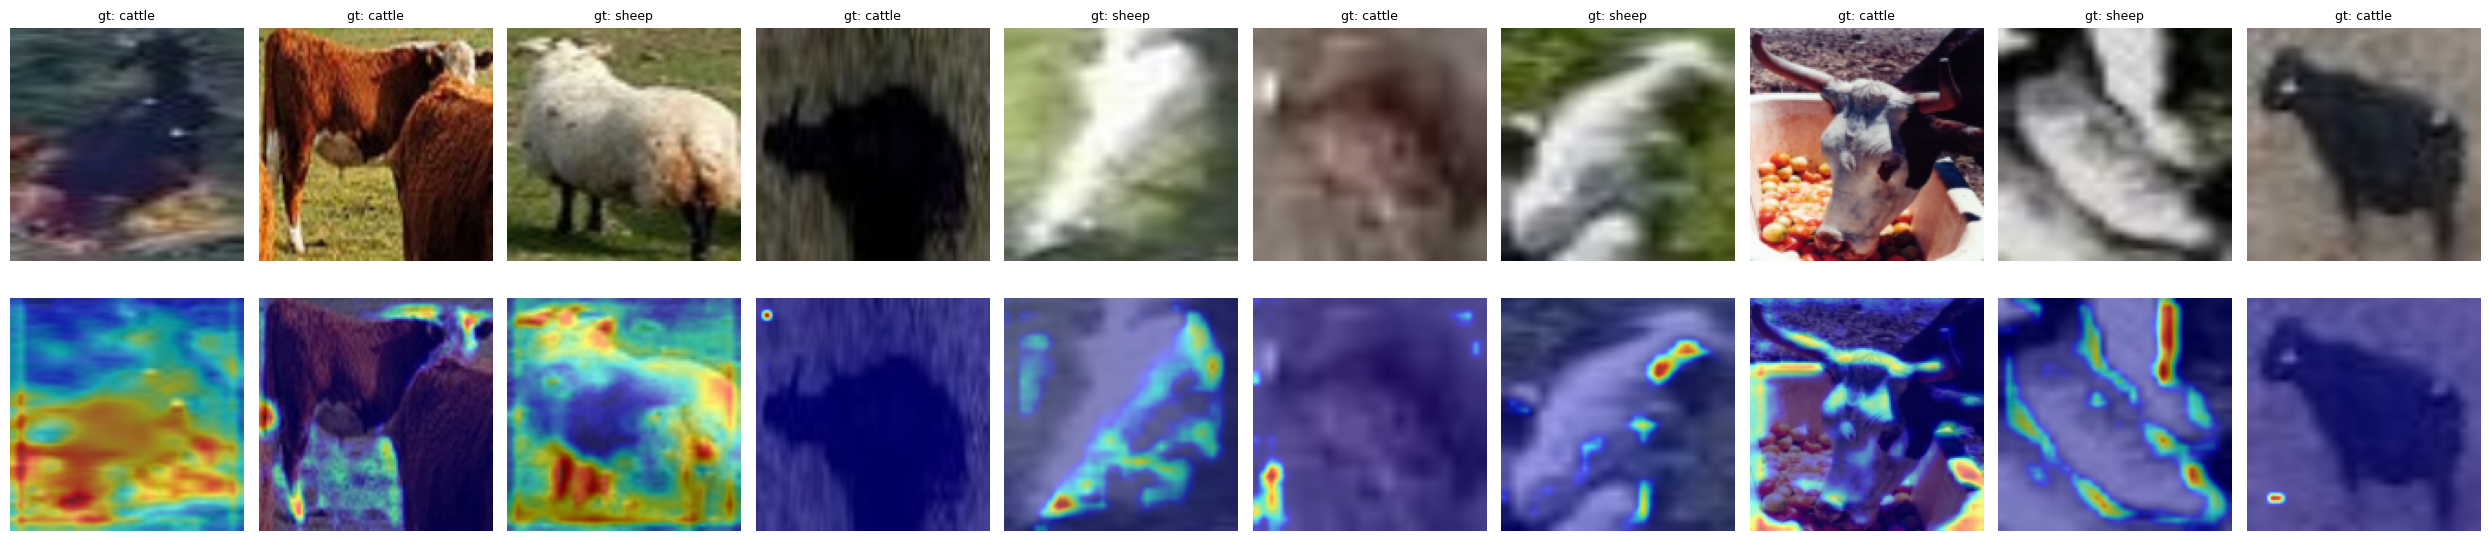

saved grad-cam grid


In [10]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

conv_layers = [m for m in final_model.features if isinstance(m, nn.Conv2d)]
target_layers = [conv_layers[-1]]
cam = GradCAM(model=final_model, target_layers=target_layers)

n_samples = 10
sample_indices = np.random.RandomState(SEED).choice(len(test_ds), size=n_samples, replace=False)

fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 2.5, 6))
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t = torch.tensor(IMAGENET_STD).view(3, 1, 1)

for i, idx in enumerate(sample_indices):
    img_tensor, label = test_ds[idx]
    img_rgb = (img_tensor * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    grayscale = cam(input_tensor=img_tensor.unsqueeze(0).to(DEVICE))[0]
    visualization = show_cam_on_image(img_rgb, grayscale, use_rgb=True)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f"gt: {classes[label]}", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(visualization)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("original", rotation=90, labelpad=10)
axes[1, 0].set_ylabel("grad-cam", rotation=90, labelpad=10)
plt.tight_layout()
plt.savefig(RUNS_DIR / "grad_cam_samples.png", dpi=100, bbox_inches="tight")
plt.show()
print("saved grad-cam grid")


In [11]:
noaug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
train_ds_noaug = ImageFolder(DATA_CROPS / "train", transform=noaug_transform)

ablation_model = SimpleCNN(
    n_conv_blocks=best_params["n_conv_blocks"],
    base_channels=best_params["base_channels"],
    kernel_size=best_params["kernel_size"],
    activation=best_params["activation"],
    dropout=best_params["dropout"],
).to(DEVICE)
ablation_optimizer = make_optimizer(best_params["optimizer"], ablation_model.parameters(), best_params["lr"])

train_loader_noaug = DataLoader(train_ds_noaug, batch_size=BS, shuffle=True, num_workers=0)
print("training ablation (no augmentation)...")
ablation_history, ablation_state, ablation_val_acc = fit_model(
    ablation_model, train_loader_noaug, full_val_loader, FINAL_EPOCHS,
    ablation_optimizer, criterion, DEVICE, patience=6, verbose=True,
)
ablation_model.load_state_dict(ablation_state)
torch.save(ablation_state, RUNS_DIR / "ablation_cnn_noaug.pt")

_, ablation_test_acc, _, _ = evaluate(ablation_model, test_loader, criterion, DEVICE)

print()
print("ablation summary:")
print(f"  with augmentation    : val_acc={best_val_acc:.4f}, test_acc={test_acc:.4f}")
print(f"  without augmentation : val_acc={ablation_val_acc:.4f}, test_acc={ablation_test_acc:.4f}")
print(f"  augmentation contribution (test acc): {test_acc - ablation_test_acc:+.4f}")

ablation_row = {
    "model": "custom_cnn_noaug",
    "val_acc": float(ablation_val_acc),
    "test_acc": float(ablation_test_acc),
    "augmentation_delta": float(test_acc - ablation_test_acc),
}
with open(RUNS_DIR / "ablation_results.json", "w") as f:
    json.dump(ablation_row, f, indent=2)
print("saved", RUNS_DIR / "ablation_results.json")


training ablation (no augmentation)...


  epoch 1: train_loss=0.3796 train_acc=0.9083 val_loss=0.1660 val_acc=0.9304 (185.4s)


  epoch 2: train_loss=0.1726 train_acc=0.9312 val_loss=0.1330 val_acc=0.9443 (181.1s)


  epoch 3: train_loss=0.1665 train_acc=0.9315 val_loss=0.1472 val_acc=0.9411 (180.2s)


  epoch 4: train_loss=0.1532 train_acc=0.9397 val_loss=0.1742 val_acc=0.9282 (185.2s)


...

  epoch 14: train_loss=0.0520 train_acc=0.9762 val_loss=0.1595 val_acc=0.9463 (181.0s)


  epoch 15: train_loss=0.0456 train_acc=0.9779 val_loss=0.1641 val_acc=0.9530 (187.2s)


  epoch 16: train_loss=0.0425 train_acc=0.9796 val_loss=0.1656 val_acc=0.9541 (181.6s)


  epoch 17: train_loss=0.0401 train_acc=0.9818 val_loss=0.1989 val_acc=0.9535 (182.2s)
  early stop at epoch 17



ablation summary:
  with augmentation    : val_acc=0.9609, test_acc=0.9610
  without augmentation : val_acc=0.9541, test_acc=0.9548
  augmentation contribution (test acc): +0.0062
saved /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/runs/baseline_cnn/ablation_results.json


In [12]:
print("custom CNN baseline: summary for comparative notebook")
print()
print(f"model params:      {sum(p.numel() for p in final_model.parameters()):,}")
print(f"img size:          {IMG_SIZE}x{IMG_SIZE}")
print(f"HP trials:         {HP_TRIALS}")
print(f"final epochs:      up to {FINAL_EPOCHS} (early stop patience 6)")
print()
print(f"test accuracy:     {test_acc:.4f}")
print(f"precision (macro): {precision:.4f}")
print(f"recall    (macro): {recall:.4f}")
print(f"f1        (macro): {f1:.4f}")
print()
print("H2 (augmentation matters): delta on test acc =", f"{test_acc - ablation_test_acc:+.4f}")
print()
print("artifacts in", RUNS_DIR)
for p in sorted(RUNS_DIR.glob("*")):
    size = p.stat().st_size / 1024
    unit = "KB" if size < 1024 else "MB"
    size = size if size < 1024 else size / 1024
    print(f"  {p.name}: {size:.1f} {unit}")


custom CNN baseline: summary for comparative notebook

model params:      8,760,706
img size:          128x128
HP trials:         15
final epochs:      up to 25 (early stop patience 6)

test accuracy:     0.9610
precision (macro): 0.9610
recall    (macro): 0.9606
f1        (macro): 0.9608

H2 (augmentation matters): delta on test acc = +0.0062

artifacts in /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/runs/baseline_cnn
  ablation_cnn_noaug.pt: 33.4 MB
  ablation_results.json: 0.1 KB
  best_cnn.pt: 33.4 MB
  grad_cam_samples.png: 1.2 MB
  optuna.db: 128.0 KB
  test_ps.npy: 60.6 KB
  test_results.json: 0.5 KB
  test_ys.npy: 60.6 KB
